# Bayesovski inverzni problemi u obradi slike
## Inverzni problemi i strojni vid - prvi projektni zadatak (tema 4)

### Doris Đivanović

## Uvod

**Inverzni problem** je problem otkrivanja, tj. rekonstrukcije, nepoznatih objekata $x$ (npr. digitalna slika ili signal) iz indirektnih i *noisy* mjerenja ili opažanja $y$.

Formalno, pretpostavljamo **model unaprijed** oblika:

$$
y = F(x) + \eta,
$$

gdje je
- $F$ takozvani *operator unaprijed* (na primjer konvolucija s jezgrom za zamućenje (*blur*) digitalne slike, matrični produkt, tomography projection, differential equation, itd.)
- $x$ je egzaktni (*true*) objekt, koji je nepoznat (na primjer *čista* digitalna slika, bez šuma, signal, itd.)
- $y$ je opažanje sa šumom (npr. zamućena slika)
- $\eta$ je šum, pogreška mjerenja

**Problem unaprijed:** Simulirati podatke primjenom operatora unaprijed $F$ na dani $x$. <br>
**Inverzni problem:** Dano je *noisy* opažanje $y$, rekonstruirati originalni $x$.

Ovaj inverzni smjer je uglavnom **loše uvjetovan**, dakle mali šum ili pogreška (*noise*) u opažanju može dovesti do jako velike greške u rješenju, tj rekonstrukciji. 

Također:
- rješenje ne mora postojati
- ako rješenje postoji, ne mora biti jedinstveno
- ako je rješenje jedinstveno, ne mora kontinuirano ovisiti o podacima.

Dakle, u praksi je direktno invertiranje sustava **nestabilno**.

Kako bi se rekonstrukcija učinila stabilnom, uvodi se **regularizacija** ili **Bayesovski pristup**.

### Deterministički i Bayesovski pristup

- **Klasični pristup:** gornji problem svodi se na loše uvjetovani problem

    $$\min_x \; \|F(x)-y\|,$$

  pa se originalni operator zamjenjuje s bolje uvjetovanim. Formulira se regularizirani optimizacijski problem:
  $$
  \min_x \; \Big(\|F(x)-y\|^2 + \lambda R(x)\Big),
  $$
  gdje je $R(x)$ regularizacijski član (npr. Tikhonovljeva regularizacija, $\ell_1, TV$).  

  Klasičan izbor je **Tikhonovljeva regularizacija**, gdje se minimizira 

    $$
    \hat{x} = \arg \min_x \Big( \|Fx - y\|^2 + \alpha \|Lx\|^2 \Big),
    $$

    gdje je
    - $F$ operator unaprijed,  
    - $L$ operator regularizacije (identiteta, matrica prvih ili drugih derivacija, Laplacian, ...),
    - $\alpha > 0$ parametar regularizacije.
      
    <br>
    
    Pristup je deterministički, nema nesigurnosti, rješenje je jedna "točka", najbolji $x$.

- **Bayesovski pristup:** 

    - Tretira pogrešku (šum) $\eta$ i nepoznati $x$ kao nezavisne slučajne varijable, čije su distribucije poznate.
    - U ovom se pristupu nepoznati $x$ naziva parametar.
    - Distribucija parametra $x$, $p(x)$, predstavlja sve ono što znamo o $x$ prije nego što smo vidjeli podatke (npr. glatkoća), dakle predstavlja apriorno znanje i u ovom se kontekstu naziva **apriorna distribucija** .   
    - Uvjetna vjerojatnost iz modela sa šumom: $p(y \mid x)$, vjerojatnost opažanja $y$ ako je dan $x$
     - Uvjetna vjerojatnost od $x$ uz dano $y$,  $p(x \mid y)$, uzima, dakle, u obzir i podatke $y$, što se može shvatiti kao ažuriranje znanja i vjerovanja o parametru $x$ i u ovom se kontekstu naziva **posteriorna distribucija**
    - Ovo je zapravo mjera od interesa i **rješenje inverznog problema** u ovom kontekstu.
    - Za računanje posteriorne distribucije - rješenja inverznog problema, koristi se Bayesov teorem:
    $$
    p(x \mid y) \propto p(y \mid x)\,p(x).
    $$
    
    Iz posteriorne distribucije možemo izvesti/zaključiti:
     - MAP (Maximum a Posteriori) procjenu - najvjerojatniji $x$
    - posteriornu sredinu/očekivanje, tj. prosječnu rekonstrukciju
    - nesigurnost - varijancu, intervale pouzdanosti, itd.
     <br><br>
     
    Dakle, ne dobivamo samo procjenu parametra koji je u nekom smislu najvjerojatniji, već i informacije o *preostaloj nesigurnosti* pri rekonstrukciji parametra, posteriornim uzorkovanjem.

    Rješenje nije jedna "točka", već cijela distribucija rješenja.

Pokazuje se da Tikhonovljeva regularizacija odgovara pretpostavci da parametar $x$ ima Gaussovu apriornu distribuciju.

## Problem unaprijed

Najprije ćemo kreirati sintetičke podatke. Zatim ćemo definirati operator unaprijed te simulirati *noisy* opažanje.

### Sintetički podaci

In [1]:
import numpy as np  # rad s poljima, linearna algebra

import matplotlib.pyplot as plt # vizualizacija

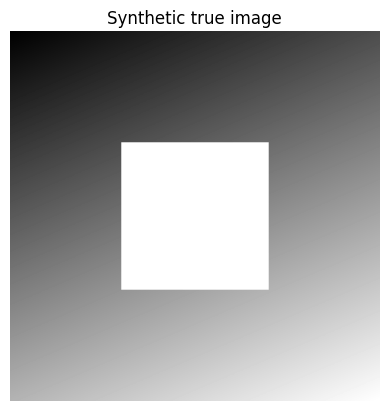

In [2]:
# generiranje sintetickih podataka - slika: bijeli kvadrat na pozadini sa sivim gradijentom
# x_true

# rezolucija slike
n = 256
# x-koordinate piksela - od 0 do 256
x = np.linspace(0, 1, n)
# Kartezijev produkt - (x,y)-koordinate piksela, x, y od 0 do 256
X, Y = np.meshgrid(x, x)

# dobivanje dijagonalnog gradijenta vrijednosti nad tom resetkom - pozadina slike
x_true = 0.3*X + 0.7*Y
# izdvajanje bijelog (odgovarajuce vrijednosti = 1) kvadrata 
# u sredistu slike
x_true[(X > 0.3) & (X < 0.7) & (Y > 0.3) & (Y < 0.7)] = 1.0

# vizualizacija slike
# bojenje piksela sivom bojom ciji je intenzitet jednak vrijednosti
plt.imshow(x_true, cmap = "gray")
plt.title("Synthetic true image")
plt.axis("off")
plt.show()

### Operator unaprijed

Naš originalni $x$ je, dakle, slika. Sada ćemo definirati operator unaprijed kao linearni operator, konvoluciju s **Gaussovim filterom**. Gaussov filter je glatka jezgra za *zamućenje* (*eng.* *blur*), sa zadanim parametrima.

Dakle, simulirat ćemo opažanje $y$ kao sliku
$$
y = A x + \eta, \qquad A x \equiv k * x,
$$
nastalu *zamućenjem* originalne slike $x \in \mathbb{R}^{n \times n}$, primjenom Gaussova filtera, jezgre za zamućenje $k$, te pretpostavljamo da šum, tj. slučajna varijabla $\eta$, ima Gaussovu distribuciju, tj.
$$\eta \sim \mathcal{N}(0,\sigma^2 I).$$

Gaussov filter zamućuje sliku na način da proširuje utjecaj svakog pojedinog piksela na okolne piksele. Jezgra je dana formulom:
$$
k[i,j] = \frac{1}{Z}\,\exp\!\Big(-\frac{i^2 + j^2}{2\sigma_k^2}\Big),
\quad Z=\sum_{i,j} \exp\!\Big(-\frac{i^2 + j^2}{2\sigma_k^2}\Big),
$$
dakle normalizira se.

Parametar $\sigma$ kontrolira koliko se proširuje utjecaj, tj. koliko je jako zamućenje. Što je $\sigma$ manji, djelovanje operatora je oštrije, tj. zamućenje je slabije, a što je $\sigma$ veći, djelovanje operatora je glađe, tj. zamućenje je jače.

In [3]:
from scipy.signal import fftconvolve   # za efikasnu konvolucujom koristenjem FFT, bez mnozenja velikih matrica
import numpy.random as rng

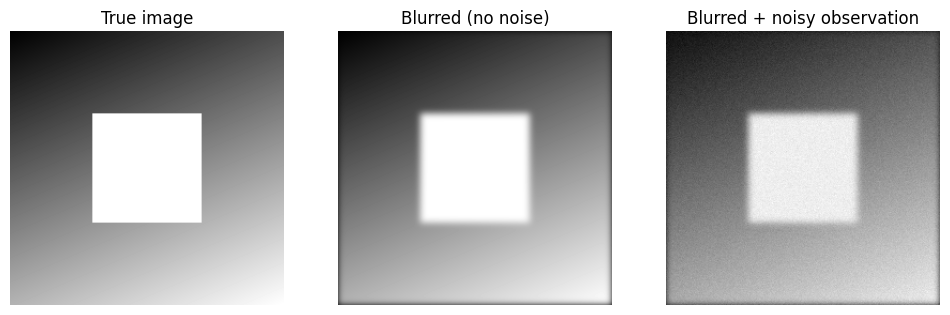

In [4]:
# defincija Gaussove jezgre
def gauss_psf(size=21, sigma=3.0):
    ax = np.arange(size) - size//2
    xx, yy = np.meshgrid(ax, ax, indexing="xy")
    k = np.exp(-(xx**2+yy**2)/(2*sigma**2))
    return k / k.sum()

# postavljanje konkretnih parametara za gaussovu jezgru
# size predstavlja velicinu jezgre: size x size 
# veci size - rasirenije zamucenje
k = gauss_psf(21, 3.0)

# konvolucija slike s gaussovom jezgrom
# tj racunanje A x
# fftconvolve - efikasna koristeci FFT
def A_apply(x_img, k):
    return fftconvolve(x_img, k, mode="same")

# dodavanje suma s gaussovom distribucijom na sliku
def add_noise(img, sigma):
    return img + sigma * rng.standard_normal(img.shape)

sigma = 0.02 # standardna devijacija suma (noise)

# dobivanje zamucene slike iz originalne
y_blur = A_apply(x_true, k)
# dobivanje opazanja dodavanjem suma na zamucenu sliku
y_obs = add_noise(y_blur, sigma)

# vizualizacija svih triju slika
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, title in zip(axs,
                         [x_true, y_blur, y_obs],
                         ["True image", "Blurred (no noise)", "Blurred + noisy observation"]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.show()


### Mjerenje degradacije originalne slike zamućenjem i dodavanjem šuma

Budući da smo za originalnu sliku generirali sintetičke podatke, ona nam je poznata, pa da bismo provjerili i ocijenili kvalitetu degradiranih slika u odnosu na originalnu sliku, možemo upotrijebiti sljedeće mjere za grešku: **Signal-to-Noise Ratio (SNR)** i  **Peak Signal-to-Noise Ratio (PSNR)**.

Signal-to-Noise omjer (SNR) definira se kao

$$
\text{SNR}(u, f) = 10 \log_{10}\left(\frac{\|f\|^2}{\|u-f\|^2}\right),
$$

gdje je $f$ originalna slika, a $u$ je slika nastala (na neki način) degradacijom originalne slike ili rekonstruirana originalna slika.
Ova vrijednost mjeri koliko je jak "signal" u donosu na pogrešku. Uspoređuje degradiranu sliku ili rekonstrukciju s originalnom. Što je vrijednost viša, to znači da je pogreška manja, odnosno da je degradirana slika ili rekonstrukcija bliža, tj. sličnija, originalnoj slici. Manje vrijednosti znače veću distorziju, zamućenje ili šum. Za *noisy* slike obično iznosi između $10$ i $30\, \text{dB}$.

**Mean Squared Error (MSE)** slike koju testiramo $u$, u odnosu na originalnu, i originalne slike $f$ je srednja vrijednost kvadrata greške po pikselu:

$$
\text{MSE}(u,f) = \frac{1}{N} \sum_{i=1}^N (u_i - f_i)^2,
$$

gdje je $N$ ukupan broj piksela, a $u_i$ i $f_i$ su vrijednosti pridružene odgovarajućim pikselima slika. Ako (i samo ako) je $u = f$, tj. npr. imamo savršenu rekonstrukciju, tada je $MSE = 0$. Veće vrijednosti znače da je testirana slika, npr. rekonstrukcija, manje blizu, tj. manje slična, originalnoj slici. Kvadriranje penalizira veće greške jače nego manje greške.

S pomoću MSE, definira se Peak Signal-to-Noise omjer (PSNR), kao:

$$
\text{PSNR}(u,f) = 20 \log_{10}\left(\frac{\max(f)}{\sqrt{\text{MSE}(u,f)}}\right).
$$

Ova vrijednost predstavlja relativnu grešku s obzirom na najveću moguću vrijednost piksela. Ponovno, što je vrijednost viša, to znači da je pogreška manja, odnosno da je degradirana slika ili rekonstrukcija bliža, tj. sličnija, originalnoj slici.

Tipične vrijednosti za PSNR (SNR je manje standardiziran):
- $> 40 \, \text{dB}$: gotovo savršena rekonstrukcija,  
- $30\!-\!40 \, \text{dB}$: dobra kvaliteta rekonstrukcije,  
- $20\!-\!30 \, \text{dB}$: umjerena degradacija,  
- $< 20 \, \text{dB}$: loša kvaliteta.

Dakle, i SNR i PSNR rastu s porastom kvalitete rekonstrukcije. Nadalje, usporedbom SNR i PSNR vrijednosti za zamućenu sliku, zamućenu sliku sa šumom, ali i rekonstrukciju dobivenu Bayesovim pristupom, možemo izmjeriti je li i koliko je rekonstrukcija bliža originalnoj slici od *noisy* slike, tj. opažanja.

In [5]:
# signal-to-noise ratio
def snr(u, f):
    #return -np.log(np.linalg.norm(u-f) / np.linalg.norm(f))
    num = np.sum(f**2)
    den = np.sum((u - f)**2)
    return 10 * np.log10(num / den)

# Peak signal-to-noise ratio
def psnr(u, f):
    #return -np.log(np.linalg.norm(u-f) / np.max(np.abs(f)))
    mse = np.mean((u - f) ** 2)
    max_val = np.max(np.abs(f))
    return 20 * np.log10(max_val / np.sqrt(mse))

print("Blurred (no noise): SNR =", snr(y_blur, x_true), "PSNR =", psnr(y_blur, x_true))
print("Blurred + noisy:   SNR =", snr(y_obs, x_true), "PSNR =", psnr(y_obs, x_true))


Blurred (no noise): SNR = 21.366673459895562 PSNR = 25.170010602285142
Blurred + noisy:   SNR = 20.825452987786484 PSNR = 24.628790130176064


Kao što je i očekivano, gornje mjere za grešku su nešto manje za sliiku nastalu primjenom samo zamućenja, nego za zamućenu sliku na koju je dodan i šum, tj. "*blurred* + *noisy*" slika je lošija od originalne nego *blurred* slika.

### Utjecaj distribucije šuma na degradaciju slike

Sada ćemo na zamućenu originalnu sliku dodati šum, tj. *noise*, s različitim vrijednostima standardne devijacije $\sigma$, te izračunati SNR i PSNR za svaku dobivenu sliku u odnosu na originalnu. 

Što je razina šuma viša, gornje mjere za grešku bi trebale opadati.

sigma=0.005 -> SNR=21.336, PSNR=25.139
sigma=0.010 -> SNR=21.224, PSNR=25.027
sigma=0.020 -> SNR=20.806, PSNR=24.609
sigma=0.050 -> SNR=18.781, PSNR=22.584
sigma=0.100 -> SNR=15.038, PSNR=18.841


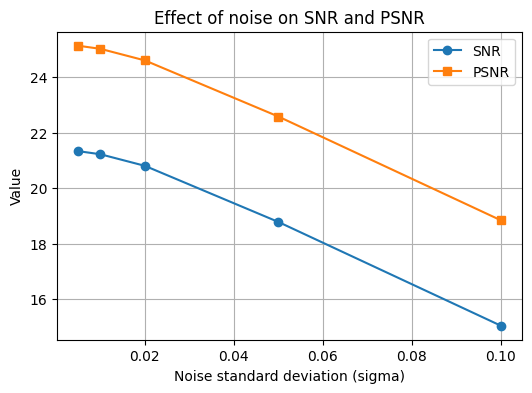

In [6]:
sigmas = [0.005, 0.01, 0.02, 0.05, 0.1] # standardne devijacije šuma koje testiramo
snr_vals, psnr_vals = [], []

for s in sigmas:
    y_obs_test = add_noise(y_blur, s)
    
    snr_vals.append(snr(y_obs_test, x_true))
    psnr_vals.append(psnr(y_obs_test, x_true))

for s, sn, ps in zip(sigmas, snr_vals, psnr_vals):
    print(f"sigma={s:0.3f} -> SNR={sn:0.3f}, PSNR={ps:0.3f}")

plt.figure(figsize=(6,4))
plt.plot(sigmas, snr_vals, "o-", label="SNR")
plt.plot(sigmas, psnr_vals, "s-", label="PSNR")
plt.xlabel("Noise standard deviation (sigma)")
plt.ylabel("Value")
plt.title("Effect of noise on SNR and PSNR")
plt.legend()
plt.grid(True)
plt.show()

### Vizualna usporedba primjene različitih razina šuma

Opadanje kvalitete slike s povećanjem standardne devijacije šuma možemo prikazati i vizualno.

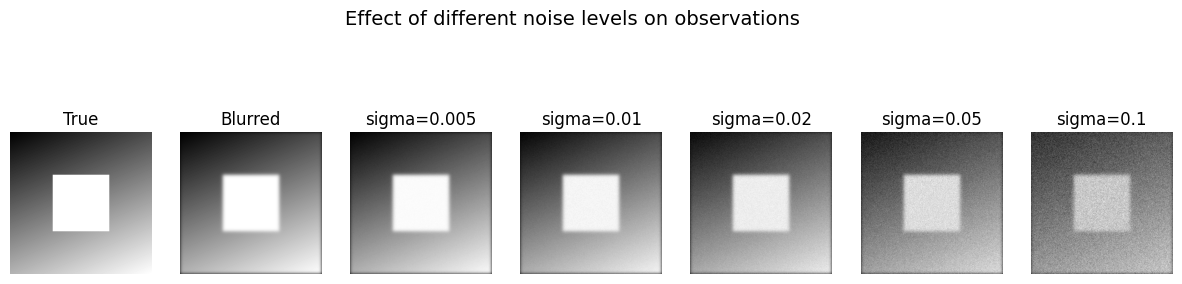

In [7]:
fig, axs = plt.subplots(1, len(sigmas)+2, figsize=(15, 4))

axs[0].imshow(x_true, cmap="gray")
axs[0].set_title("True")
axs[0].axis("off")

axs[1].imshow(y_blur, cmap="gray")
axs[1].set_title("Blurred")
axs[1].axis("off")

for i, s in enumerate(sigmas):
    y_obs_test = add_noise(y_blur, s)
    axs[i+2].imshow(y_obs_test, cmap="gray")
    axs[i+2].set_title(f"sigma={s}")
    axs[i+2].axis("off")

plt.suptitle("Effect of different noise levels on observations", fontsize=14)
plt.show()

## Bayesov model

Gornjim postupkom simulirali smo opažanje, tj. zamućenu *noisy* sliku konvolucijom i šumom s Gaussovom distribucijom. To je upravo situacija koja se promatra u Bayesovom pristupu, gdje modeliramo opažanje kao

$$
y = A x + \eta, \quad \eta \sim \mathcal{N}(0, \sigma^2 I).
$$

Vjerojatnost iz modela, $p(y \mid x)$, govori nam koliko je vjerojatno da se opazi $y$ uz dani $x$. Budući da je šum, tj. *noise*, gaussovski, vjerojatnost je oblika
$$
p(y \mid x) \propto \exp\!\left(-\frac{1}{2\sigma^2}\|Ax - y\|_2^2\right).
$$

Interpretacija je sljedeća: ukoliko je $Ax \approx y$, eksponent je mali, pa je vjerojatnost velika. Nadalje, ukoliko je $Ax$ *daleko* od $y$, vjerojatnost je mala. Dakle, ovo penalizira neusklađenost između $Ax$ i $y$.

Dakle, $p(y \mid x)$ govori nam koliko je opažena slika $y$ vjerojatna, ako je originalna slika bila $x$. Što je zamućena slika $x$, dakle $Ax$, bliža, tj. sličnija, izmjerenom ili opaženom $y$, vjerojatnost je veća. Penalizira se neusklađenost između kandidata $Ax$ i izmjerenog $y$.

Budući da je problem loše postavljen, puno mogućih $x$ može biti rješenje za isti $y$. Stoga, da bismo stabilizirali problem, pretpostavljamo apriornu distribuciju od $x$, dakle apriorno vjerovanje ili znanje o tome kako izgleda $x$. Ovime ćemo preferirati *razumnija* rješenja.

Pretpostavljamo Gaussovu apriornu distribuciju:
$$
p(x) \propto \exp\!\left(-\frac{\alpha}{2} \|R^{1/2} x\|_2^2\right),
$$

gdje je $\alpha$ opet tzv. parametar regularizacije, a $R$ operator regularizacije, npr. $R = I$ (identiteta) - penalizira veliki $\|x\|_2$, tj. preferira rješenja s malom normom, ili $R = L^\top L$, gdje je $L$ diskretni Laplacian - preferira, tj. podržava, glatkoću, tj. glatke slike.

Ovo je upravo ideja Tikhonovljeve regularizacije, ali predstavljena ne na deterministički, već probabilistički način.

Prema Bayesovu teoremu, posteriorna distribucija je
$$
p(x \mid y) \propto p(y \mid x)\,p(x),
$$
dakle ona kombinira vjerojatnost $p(y \mid x)$, dakle usklađuje podatke, i apriornu distribuciju $p(x)$, dakle podržava glatkoću i stabilnost.
  
Budući da oba člana imaju Gaussovu distribuciju, posteriorna distribucija je također Gaussova s
$$
Q = \frac{1}{\sigma^2} A^\top A + \alpha R,
$$
dakle s kovarijancom $Q^{-1}$, i očekivanjem
$$
\mu_{\text{post}} = Q^{-1} \frac{1}{\sigma^2} A^\top y.
$$

MAP (Maximum a Posteriori) procjena je najvjerojatnija rekonstrukcija $x$ za dani $y$. U slučaju Gaussove distribucije jednak je očekivanju, pa se može dobiti rješavanjem sustava:
$$
Q x_{\text{MAP}} = \frac{1}{\sigma^2} A^\top y = b.
$$

Ovaj linearni sustav je tzv. regularizirani problem rekonstrukcije. Egzaktno odgovara najmanjim kvadratima s Tikhonovljevom regularizacijom. Međutim, za razliku od klasične regularizacije, Bayesov pristup daje ne samo jedno rješenje, već i kovarijancu, dakle uvid u posteriornu *nesigurnost*.


### Rješavanje linearnog sustava

Dakle, moramo riješiti sustav
$$Qx = b,$$
gdje je 
$$Q = \frac{1}{\sigma^2} A^\top A + \alpha R, \qquad b = \frac{1}{\sigma^2} A^\top y.$$

Dakle, potrebno je najprije izračunati operator $Q$ i vektor desne strane $b$.

Za operator $Q$ potrebno je odrediti konkretni parametar regularizacije $\alpha$ i konkretni operator regularizacije $R$.

U praksi su matrice $A$, $A^\top$ i $Q$ jako velike, pa ih nećemo eksplicitno kreirati. 

Konvolucije $Ax$ ili $A\top x$ mogu se efikasno provesti korištenjem FFT, što nam omogućava funkcija `fftconvolve` iz modula `scipy.signal`.

Umjesto eksplicitnog formiranja operatora $Q$, možemo ga reprezentirati implicitno, definirajući *samo* djelovanje $Q$ na vektor, što nam omogućava funkcija `LinearOperator` iz modula `scipy.sparse.linalg`. 

U istom modulu nalazi se tzv. *Conjugate Gradient* solver `cg`, koji omogućava iterativno rješavanje sustava s operatorom kreiranim s `LinearOperator`, dakle bez eksplicitnog kreiranja operatora - prikladno za velike linearne sustave.


In [8]:
from scipy.sparse.linalg import LinearOperator, cg

**Napomena.** Pokušati s različitim operatorima $R$.

In [9]:
from scipy.ndimage import laplace

# definicija konkretnog operatora regularizacije R(x) za apriornu distrbuciju

def R_apply_1(z_img):
    return z_img  # identiteta 
    
def R_apply_2(z_img):
    return laplace(z_img)  # diskretni Laplacian

def R_apply_3(z_img):
    Lz = laplace(z_img) 
    return Lz / (np.max(np.abs(Lz)) + 1e-12) # normalizirani laplacian

def R_apply_4(z_img):
    lap = (-4*z_img
           + np.roll(z_img, 1, 0) + np.roll(z_img, -1, 0)
           + np.roll(z_img, 1, 1) + np.roll(z_img, -1, 1))
    return lap

In [10]:
# PARAMETAR REGULARIZACIJE 
alpha = 1e-2 

# efikasno racunanje A^T y / sigma^2 - desna strana sustava
# ovo je zapravo konvolucija s preokrenutom jezgrom
At_y = fftconvolve(y_obs, k[::-1, ::-1], mode = "same") / (sigma**2) 

# defincija Q(x) = (A^T A / sigma^2)x + alpha R(x)
# izrazena bez matrice, koristenjem fftconvolve
def Q_apply(z_flat):
    z = z_flat.reshape(x_true.shape)
    Az = A_apply(z, k)
    AtAz = fftconvolve(Az, k[::-1, ::-1], mode="same")
    q = (AtAz / (sigma**2)) + alpha * R_apply_1(z)  # ==> PRIMIJENITI ODGOVARAJUCI R
    return q.ravel()

# linearni operator za cg solver
# LinearOperator iz Q_apply kreira objekt koji se ponasa kao matrica
# njega cemo dati kao parametar solveru cg
linop = LinearOperator((x_true.size, x_true.size), matvec = Q_apply)

# vektor desne strane, oznacen s b
b = At_y.ravel()

### Određivanje rekonstrukcije kao MAP procjenitelja i usporedba s opažanjem

Sada smo efikasno izračunali, tj. reprezentirali, operator $Q$ i vektor desne strane $b$, dakle pripremili smo sustav
$$Qx = b,$$
čije rješenje želimo naći kako bismo dobili MAP procjenitelj.

Ovako kreirane $Q$ i $b$ predat ćemo kao parametre *Conjugate Gradient* solver-u, dakle riješiti pripadni sustav i dobiti MAP procjenitelj.

Iterativni `cg` slover kao parametre prima i maksimalni broj iteracija te toleranciju, tj. ocjenu za rezidual, uvjet zaustavljanja - solver stane kada je rezidual dovoljno mali.

Uz MAP procjenitelj, `cg` solver vraća i `info` - ako je `info`$= 0$, znači da je konvergirao prema rješenju. Ukoliko je `info` = `maxiter`, znači da je solver dostigao maksimalni broj iteracija, a nije našao dovoljno dobro rješenje sustava, dakle nije pravilno konvergirao prema rješenju. U tom slučaju treba povećati maksimalni broj iteracija ili povećati parametar $\alpha$.

Kako bismo usporedili dobiveni MAP procjenitelj, tj. rekonstrukciju, dakle rješenje linearnog sustava za konkretne $\alpha$ i $R$, s opažanjem $y$, dakle sa zamućenom originalnom slikom sa šumom, tj. usporedili njihove sličnosti s originalnom slikom $x$, vizualizirat ćemo originalnu sliku $x$, opažanje $y$ te MAP rekonstrukciju. MAP rekonstrukcija trebala bi svakako biti s manjim *smetnjama*, tj. manje *noisy* nego $y$.

Nadalje, kako bismo usporedili MAP rekonstrukciju i opažanje $y$, dakle njihove sličnosti s originalnom slikom $x$, izračunat ćemo metrike SNR i PSNR. U skladu s prethodnim objašnjenjem ovih metrika, očekujemo da su SNR i PSNR za MAP rekonstrukciju svakako veće od onih za opažanje $y$.

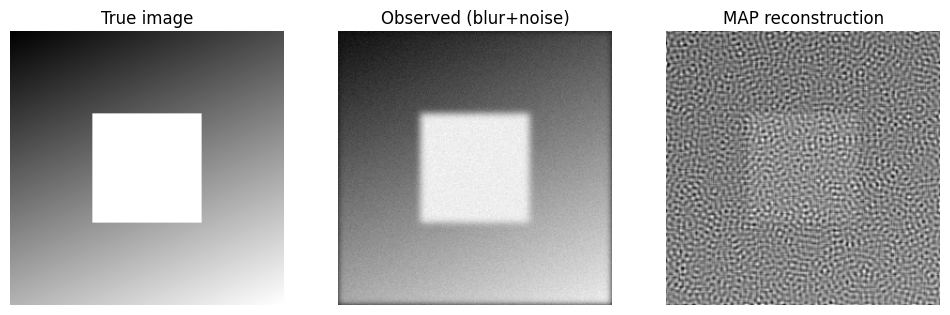

In [11]:
# rjesavanje sustava Q x = b s pomocu CG
# rtol = 1e-6 = relative tolerance ==> solver stane kad je rezidual dovoljno mali
x_map_flat, info = cg(linop, b, maxiter = 2000, rtol = 1e-6)  # maxiter = 300
if info != 0: # info = 0 ==> success
    print(f"CG finished with info={info} (0 means converged)")

x_map = x_map_flat.reshape(x_true.shape)

# vizualizacija
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
for ax, im, title in zip(
    axs,
    [x_true, y_obs, x_map],
    ["True image", "Observed (blur+noise)", "MAP reconstruction"],
):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.show()

In [12]:
# metrike
print("MAP  SNR :", snr(x_map, x_true))
print("MAP PSNR :", psnr(x_map, x_true))

MAP  SNR : -3.837041696553248
MAP PSNR : -0.033704554163668736


### Traženje dovoljno dobrog parametra $\alpha$ za fiksan operator $R$

Sada ćemo za fiksan operator regularizacije $R$, definiran odgovarajućom funkcijom `R_apply` u ćeliji ranije, izračunati MAP rekonstrukciju za različite vrijednosti parametra regularizacije $\alpha$. Usput ćemo računati pripadne PSNR vrijednosti za svaku dobivenu MAP rekonstrukciju s obzirom na originalnu sliku. *Najbolji* $\alpha$ od testiranih bit će onaj za kojeg je PSNR vrijednost najveća.

Kako bismo i vizualno potvrdili da odabrani $\alpha$ stvarno bolje rekonstruira originalnu sliku, vizualizirat ćemo pripadnu rekonstrukciju.

alpha=0.0010 -> PSNR=1.735
alpha=0.0032 -> PSNR=2.161
alpha=0.0100 -> PSNR=3.353
alpha=0.0316 -> PSNR=6.083
alpha=0.1000 -> PSNR=10.463
alpha=0.3162 -> PSNR=15.385
alpha=1.0000 -> PSNR=20.202
alpha=3.1623 -> PSNR=24.619
alpha=10.0000 -> PSNR=27.958
Best alpha: 10, PSNR=27.9579


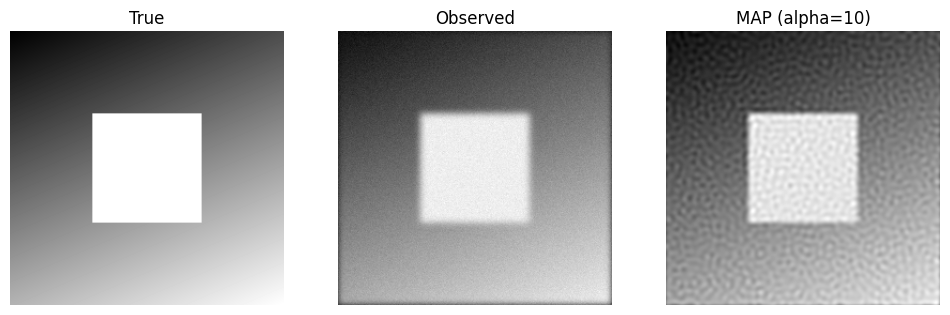

In [13]:
def solve_map(alpha_val):
    def Q_apply_alpha(z_flat):
        z = z_flat.reshape(x_true.shape)
        Az = A_apply(z, k)
        AtAz = fftconvolve(Az, k[::-1, ::-1], mode = "same")
        q = (AtAz / (sigma**2)) + alpha_val * R_apply_1(z)   # ==> PRIMIJENITI ODGOVARAJUCI R
        return q.ravel()

    linop_alpha = LinearOperator((x_true.size, x_true.size), matvec = Q_apply_alpha)
    x_flat, info = cg(linop_alpha, b, maxiter=300, rtol=1e-6)
    return x_flat.reshape(x_true.shape)

alphas = 10.0**np.linspace(-3, 1, 9)  #np.linspace(-3, 1, 9)  # alpha od 0.001 do 10   #np.linspace(-4, -1, 7)   # alpha od 0.0001 do 0.1
best = (None, -np.inf, None)
for a in alphas:
    x_try = solve_map(a)
    score = psnr(x_try, x_true)
    print(f"alpha={a:.4f} -> PSNR={score:.3f}")
    if score > best[1]:
        best = (a, score, x_try)

alpha_best, psnr_best, x_map = best
print(f"Best alpha: {alpha_best:.4g}, PSNR={psnr_best:.4f}")

# vizualizacija
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(x_true, cmap="gray"); plt.title("True"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(y_obs, cmap="gray"); plt.title("Observed"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(x_map, cmap="gray"); plt.title(f"MAP (alpha={alpha_best:.3g})"); plt.axis("off")
plt.show()


Iz gornje vizualizacije, vidimo da je MAP rekonstrukcija za *najbolji* parametar $\alpha$ stvarno puno bolja rekonstrukcija originalne slike od MAP rekonstrukcije za ranije postavljenu vrijednost parametra $\alpha$. MAP za *najbolji* parametar $\alpha$ puno je jasnije rekonstruirao rubove.

### Graf konvergencije

Za pojedini parametar $\alpha$ možemo nacrtati graf konvergencije `cg` solvera prema rješenju, na kojem ćemo promatrati postojanje i brzinu konvergencije. 

Poziv `cg` solvera trebamo modificirati tako da dinamički, za svaku iteraciju, računa pripadni rezidual te njegovu normu. Norme reziduala za svaku iteraciju akumulirat ćemo u listu, koja će nam poslužiti za crtanje grafa konvergencije vizualizirajući odgovarajuće vrijednosti za indeks svake provedene iteracije.

Niz normi reziduala trebao bi biti monotono padajući, ili barem imati padajući *trend*.

Brzina konvergencije bit će vidljiva iz broja provedenih iteracija.

CG info for alpha = 10.0 0


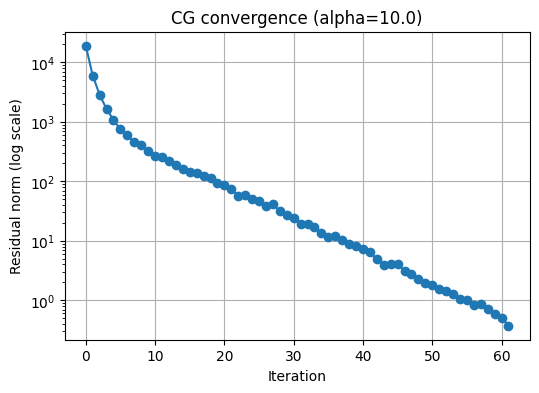

In [14]:
residuals = []

def cg_callback(xk):
    # rezidual r_k = b - Q x_k
    r = b - linop.matvec(xk)     # za LinearOperator koristi se .matvec(...)
    # ekvivakentno r = b - (linop @ xk) 
    residuals.append(np.linalg.norm(r))

# cg solver koji dinamicki racuna norme reziduala
def solve_map_with_residuals(alpha_val):
    def Q_apply_alpha(z_flat):
        z = z_flat.reshape(x_true.shape)
        Az = A_apply(z, k)
        AtAz = fftconvolve(Az, k[::-1, ::-1], mode="same")
        q = (AtAz / (sigma**2)) + alpha_val * R_apply_1(z)    # ==> PRIMIJENITI ODGOVARAJUCI R
        return q.ravel()

    linop_alpha = LinearOperator((x_true.size, x_true.size), matvec=Q_apply_alpha)
    residuals.clear()
    x_flat, info = cg(linop_alpha, b, rtol=1e-6, maxiter=2000, callback=cg_callback)
    return x_flat.reshape(x_true.shape), residuals, info
    
alpha = alpha_best # ===> POSTAVITI PARAMETAR alpha

x_best, residuals, info = solve_map_with_residuals(alpha)  

print(f"CG info for alpha = {alpha}", info)

# graf - vrijednosti normi pripadnog reziduala za svaku provedenu iteraciju
plt.figure(figsize=(6,4))
plt.semilogy(residuals, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Residual norm (log scale)")
plt.title(f"CG convergence (alpha={alpha})")
plt.grid(True)
plt.show()

# Literatura

- prof. dr. sc. Luka Grubišić, nastavni materijali iz kolegija Inverzni problemi i strojni vid, ak. god. 2024./2025., PMF - MO, Zagreb
- https://numerik.mi.fu-berlin.de/wiki/SS_2022/InverseProblems_Dokumente/week5.pdf
- https://en.wikipedia.org/wiki/Signal-to-noise_ratio